In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random

In [2]:
# Настройки
DATA_DIR = '/app/urban-layer-dataset_25d/'
GRID_Z_MAX = 32  # Для перевода нормализованной высоты обратно в индексы

In [3]:
def inspect_2d_sample(npz_path):
    filename = os.path.basename(npz_path)
    print(f"\n{'='*60}")
    print(f"Inspecting: {filename}")
    
    # 1. Загрузка
    data = np.load(npz_path)
    x = data['x']  # (6, 128, 128)
    y = data['y']  # (5, 128, 128)
    
    # 2. Распаковка ВХОДОВ (Inputs)
    # [BuildH, SDF, LAI, SourceH, WindX, WindY]
    build_h_map = x[0]
    sdf_map     = x[1]
    lai_map     = x[2]
    source_h_map= x[3]
    wind_x      = x[4, 0, 0] # Константа
    wind_y      = x[5, 0, 0] # Константа
    
    # 3. Распаковка ВЫХОДОВ (Targets)
    # [Z=1, Z=5, Z=8, Z=25, Mean]
    conc_z1   = y[0]  # Земля (~3м)
    conc_z5   = y[1]  # Низкая застройка (~10м)
    conc_z8   = y[2]  # Средняя высота (~16м)
    conc_z25  = y[3]  # Высоко (~50м)
    conc_mean = y[4]  # Интеграл
    
    # 4. Анализ физики (текстовый)
    # Источник
    src_pixels = source_h_map[source_h_map > 0]
    if len(src_pixels) > 0:
        h_norm = src_pixels.max()
        h_idx = h_norm * GRID_Z_MAX
        print(f"[SOURCE] Height Norm: {h_norm:.2f} | Index Z ≈ {h_idx:.1f}")
        if h_idx < 1.0: print(" -> Type: ROAD emission (Ground)")
        else:           print(" -> Type: STACK emission (Roof/Elevated)")
    else:
        print("[SOURCE] WARNING: Mask is empty!")
        
    # Ветер
    w_mag = np.sqrt(wind_x**2 + wind_y**2)
    print(f"[WIND]   Vector: ({wind_x:.2f}, {wind_y:.2f}) | Magnitude: {w_mag:.2f}")

    # 5. Визуализация
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    plt.suptitle(f"Sample: {filename}", fontsize=16)
    
    # --- ROW 1: INPUT FEATURES ---
    
    # 1.1 Geometry (Height Map + SDF contours)
    ax = axes[0, 0]
    im = ax.imshow(build_h_map, cmap='bone', origin='lower', vmin=0, vmax=1)
    ax.contour(sdf_map, levels=[0.01], colors='cyan', linewidths=0.5) # Контуры стен
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Norm Height')
    ax.set_title("Input: Building Height Map")
    
    # 1.2 Vegetation (LAI)
    ax = axes[0, 1]
    im = ax.imshow(lai_map, cmap='YlGn', origin='lower')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='LAI Sum')
    # Наложим контуры зданий, чтобы видеть, не растут ли деревья в стенах
    ax.contour(build_h_map, levels=[0.01], colors='black', linewidths=0.5)
    ax.set_title("Input: Vegetation (LAI)")
    
    # 1.3 Source Height
    ax = axes[0, 2]
    # Используем маску, чтобы 0 был прозрачным или фоновым
    src_masked = np.ma.masked_where(source_h_map == 0, source_h_map)
    # Фон - серая геометрия для контекста
    ax.imshow(build_h_map > 0, cmap='binary', origin='lower', alpha=0.3)
    im = ax.imshow(src_masked, cmap='plasma', origin='lower', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Source Height')
    ax.set_title("Input: Source Location")
    
    # 1.4 Wind Direction (Visual)
    ax = axes[0, 3]
    ax.text(0.5, 0.5, "WIND", ha='center', va='center', fontsize=20)
    # Рисуем стрелку из центра
    dx, dy = wind_x/w_mag, wind_y/w_mag
    ax.arrow(0.5, 0.5, dx*0.3, dy*0.3, head_width=0.05, color='blue', transform=ax.transAxes, linewidth=3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Input: Wind Dir\n({wind_x:.1e}, {wind_y:.1e})")

    # --- ROW 2: TARGET CONCENTRATIONS (Different Heights) ---
    
    # Общая нормализация цвета для сравнения слоев (берем 99 перцентиль, чтобы убрать шум -9999)
    vmax = np.percentile(conc_z1, 99.5) if conc_z1.max() > 0 else 1.0
    
    # 2.1 Ground Level (Z=1)
    ax = axes[1, 0]
    im = ax.imshow(conc_z1, cmap='turbo', origin='lower', vmin=0, vmax=vmax)
    # Контуры зданий обязательны - шлейф должен их обтекать!
    ax.contour(build_h_map, levels=[0.01], colors='white', linewidths=0.5)
    ax.set_title("Target: Ground (Z=1 ~3m)")
    
    # 2.2 Mid Level (Z=8)
    ax = axes[1, 1]
    im = ax.imshow(conc_z8, cmap='turbo', origin='lower', vmin=0, vmax=vmax)
    # Здесь контуры зданий только тех, что выше Z=8 (norm height > 8/32 = 0.25)
    ax.contour(build_h_map, levels=[0.25], colors='white', linewidths=0.5, linestyles='--')
    ax.set_title("Target: Mid-Roof (Z=8 ~16m)")
    
    # 2.3 High Level (Z=25)
    ax = axes[1, 2]
    im = ax.imshow(conc_z25, cmap='turbo', origin='lower', vmin=0, vmax=vmax)
    ax.set_title("Target: High (Z=25 ~50m)")
    
    # 2.4 Mean Concentration
    ax = axes[1, 3]
    im = ax.imshow(conc_mean, cmap='magma', origin='lower') # Другая палитра для среднего
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mean Conc')
    ax.set_title("Target: Vertical Mean")

    plt.tight_layout()
    plt.show()

Found 975 files. Showing 3 random samples...

Inspecting: build_cuda1222_scale__output_2026_1_11_22_6_39__tracer14.npz
[SOURCE] Height Norm: 0.06 | Index Z ≈ 2.0
 -> Type: STACK emission (Roof/Elevated)
[WIND]   Vector: (-0.00, 0.00) | Magnitude: 0.00


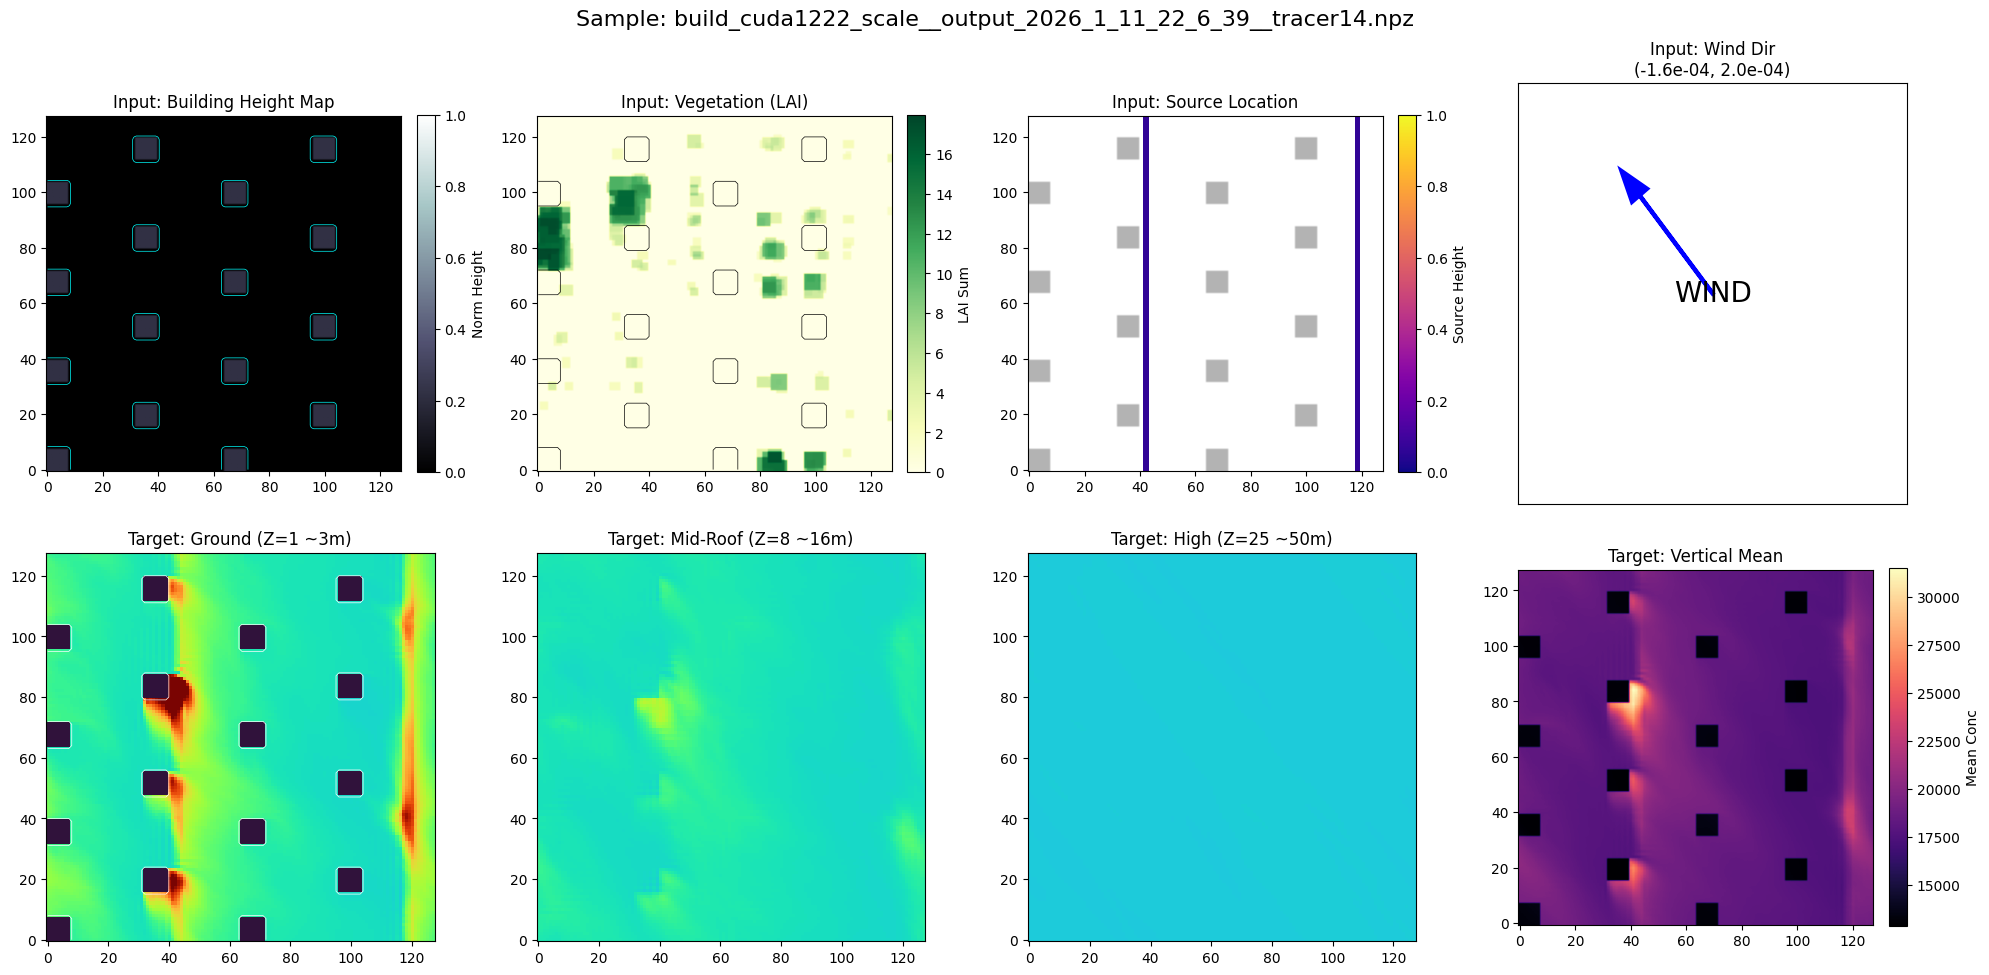


Inspecting: build_cuda1222_scale__output_2026_1_12_4_50_45__tracer30.npz
[SOURCE] Height Norm: 0.06 | Index Z ≈ 2.0
 -> Type: STACK emission (Roof/Elevated)
[WIND]   Vector: (-0.00, -0.00) | Magnitude: 0.00


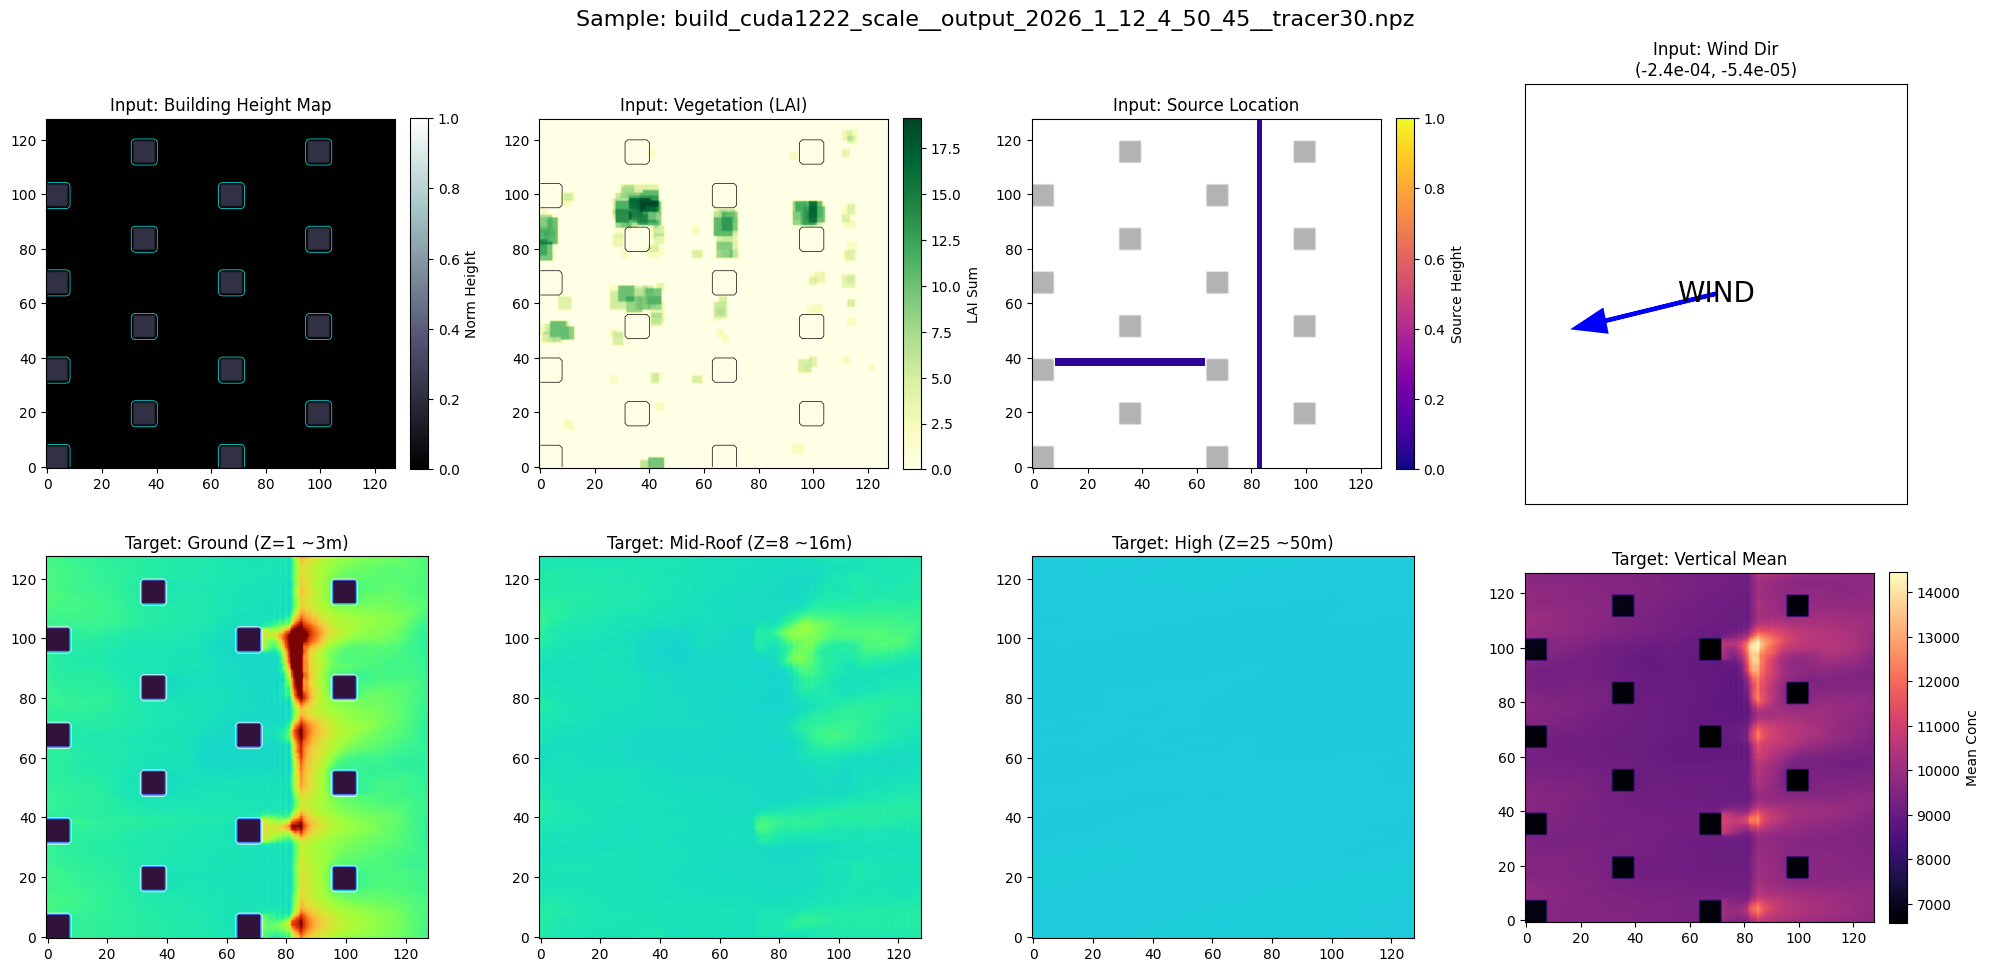


Inspecting: build_cuda1222_scale__output_2026_1_11_14_49_20__tracer20.npz
[SOURCE] Height Norm: 0.06 | Index Z ≈ 2.0
 -> Type: STACK emission (Roof/Elevated)
[WIND]   Vector: (0.00, -0.00) | Magnitude: 0.00


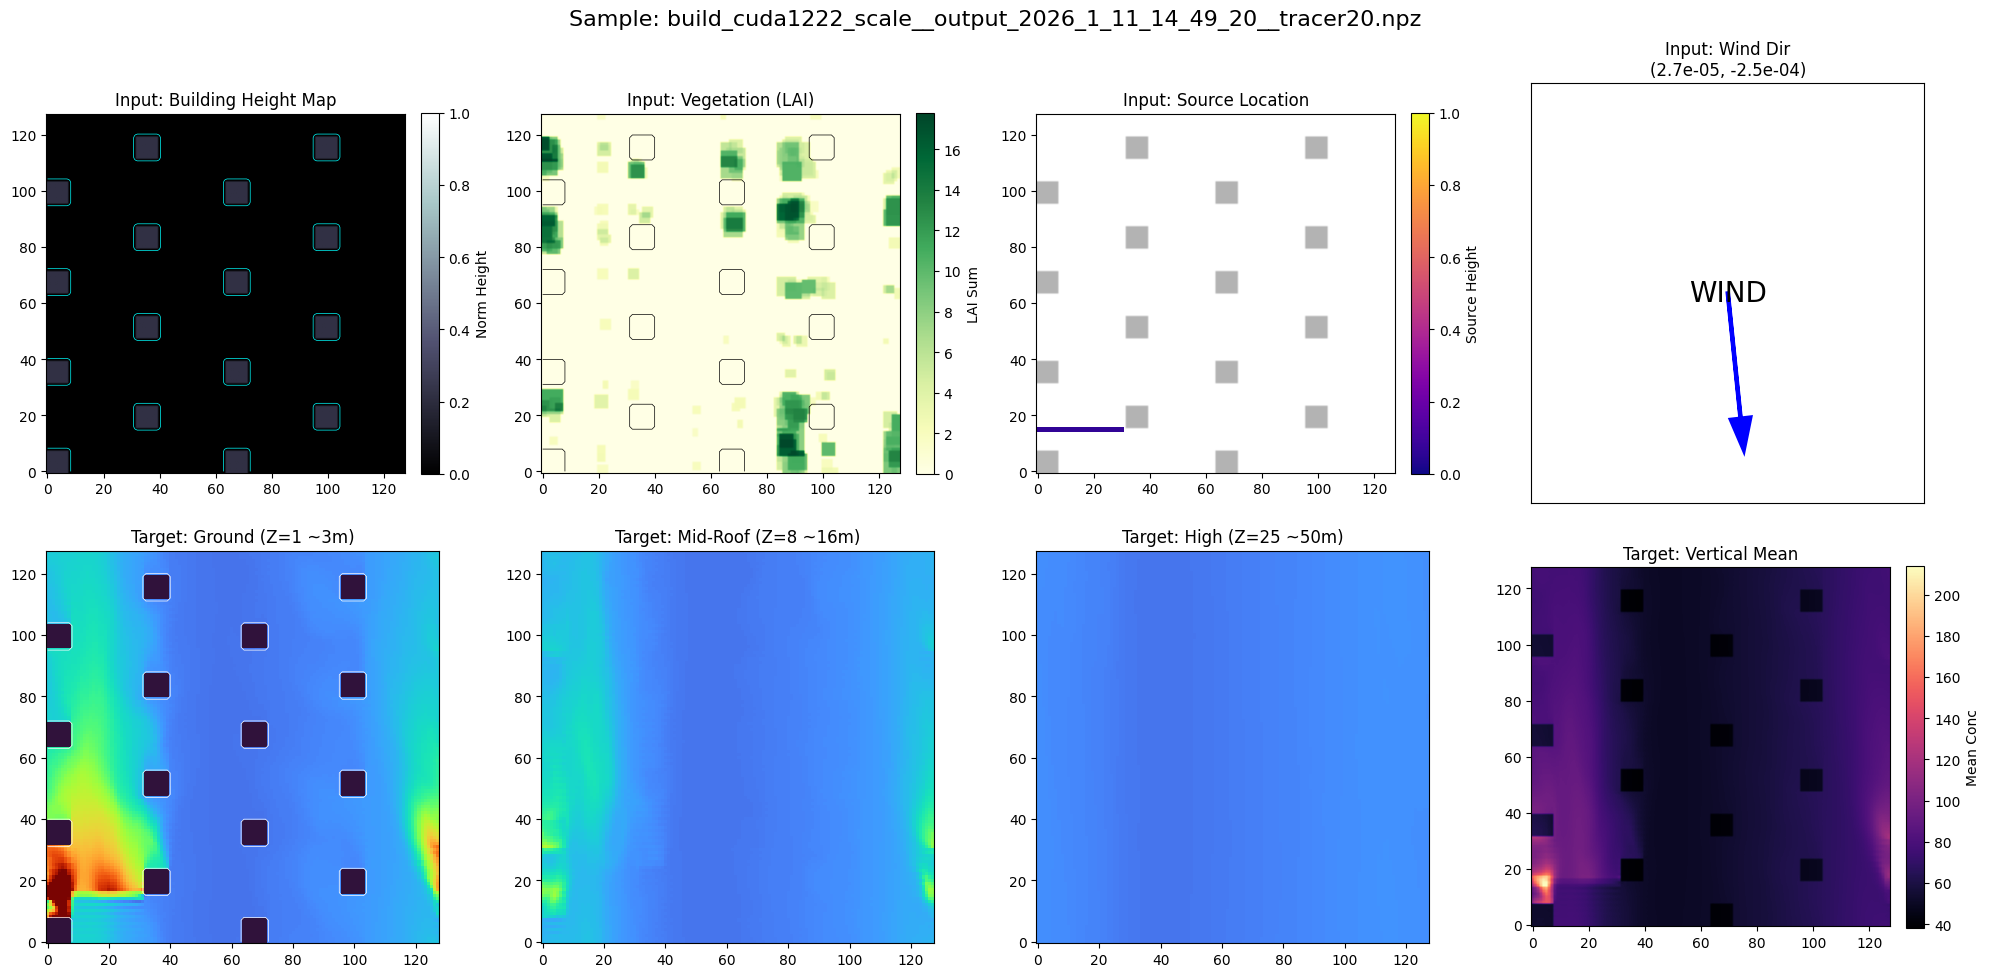

In [4]:
files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
if not files:
    print("No dataset found!")
    
print(f"Found {len(files)} files. Showing 3 random samples...")
# Берем случайные сэмплы
samples = random.sample(files, 3)

for f in samples:
    inspect_2d_sample(f)